Exp 10. Iris Flower Classification: Use the Iris dataset to build a classification model that
predicts the species of iris flowers. [Dataset: Load dataset from sklearn]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score,roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Load Iris dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

In [ ]:
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [ ]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [ ]:
# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
X_scaled

array([[-9.00681170e-01,  1.01900435e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00, -1.31979479e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.38535265e+00,  3.28414053e-01, -1.39706395e+00,
        -1.31544430e+00],
       [-1.50652052e+00,  9.82172869e-02, -1.28338910e+00,
        -1.31544430e+00],
       [-1.02184904e+00,  1.24920112e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-5.37177559e-01,  1.93979142e+00, -1.16971425e+00,
        -1.05217993e+00],
       [-1.50652052e+00,  7.88807586e-01, -1.34022653e+00,
        -1.18381211e+00],
       [-1.02184904e+00,  7.88807586e-01, -1.28338910e+00,
        -1.31544430e+00],
       [-1.74885626e+00, -3.62176246e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00,  9.82172869e-02, -1.28338910e+00,
        -1.44707648e+00],
       [-5.37177559e-01,  1.47939788e+00, -1.28338910e+00,
        -1.31544430e+00],
       [-1.26418478e+00,  7.88807586e-01, -1.22655167e+00,
      

In [ ]:
# Initialize Models
LR = LogisticRegression(max_iter=1000)
RF = RandomForestClassifier(n_estimators=100, random_state=42)
XGB = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
DT = DecisionTreeClassifier(random_state=42)
KNN = KNeighborsClassifier(n_neighbors=5)

# Fit Models
LR.fit(X_train, y_train)
RF.fit(X_train, y_train)
XGB.fit(X_train, y_train)
DT.fit(X_train, y_train)
KNN.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:06:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


KNeighborsClassifier()

In [ ]:
# ---  Accuracy Scores ---
lr_acc = accuracy_score(y_test, LR.predict(X_test))
rf_acc = accuracy_score(y_test, RF.predict(X_test))
xgb_acc = accuracy_score(y_test, XGB.predict(X_test))
dt_acc = accuracy_score(y_test, DT.predict(X_test))
knn_acc = accuracy_score(y_test, KNN.predict(X_test))

print(f"Logistic Regression Accuracy: {lr_acc}")
print(f"Random Forest Accuracy: {rf_acc}")
print(f"XGBoost Accuracy: {xgb_acc}")
print(f"Decision Tree Accuracy: {dt_acc}")
print(f"K-Nearest Neighbors Accuracy: {knn_acc}")

Logistic Regression Accuracy: 1.0
Random Forest Accuracy: 1.0
XGBoost Accuracy: 1.0
Decision Tree Accuracy: 1.0
K-Nearest Neighbors Accuracy: 1.0


In [ ]:
# --- Precision Scores ---
lr_precision = precision_score(y_test, LR.predict(X_test), average='weighted')
rf_precision = precision_score(y_test, RF.predict(X_test), average='weighted')
xgb_precision = precision_score(y_test, XGB.predict(X_test), average='weighted')
dt_precision = precision_score(y_test, DT.predict(X_test), average='weighted')
knn_precision = precision_score(y_test, KNN.predict(X_test), average='weighted')

print(f"LR Precision:  {lr_precision:.4f}")
print(f"RF Precision:  {rf_precision:.4f}")
print(f"XGB Precision: {xgb_precision:.4f}")
print(f"DT Precision:  {dt_precision:.4f}")
print(f"KNN Precision: {knn_precision:.4f}")

LR Precision:  1.0000
RF Precision:  1.0000
XGB Precision: 1.0000
DT Precision:  1.0000
KNN Precision: 1.0000


In [ ]:
# --- Recall Scores ---
lr_recall = recall_score(y_test, LR.predict(X_test), average='weighted')
rf_recall = recall_score(y_test, RF.predict(X_test), average='weighted')
xgb_recall = recall_score(y_test, XGB.predict(X_test), average='weighted')
dt_recall = recall_score(y_test, DT.predict(X_test), average='weighted')
knn_recall = recall_score(y_test, KNN.predict(X_test), average='weighted')

print(f"\nLR Recall:     {lr_recall:.4f}")
print(f"RF Recall:     {rf_recall:.4f}")
print(f"XGB Recall:    {xgb_recall:.4f}")
print(f"DT Recall:     {dt_recall:.4f}")
print(f"KNN Recall:    {knn_recall:.4f}")


LR Recall:     1.0000
RF Recall:     1.0000
XGB Recall:    1.0000
DT Recall:     1.0000
KNN Recall:    1.0000


In [ ]:
# --- ROC-AUC Scores ---

lr_auc = roc_auc_score(y_test, LR.predict_proba(X_test), multi_class='ovr')
rf_auc = roc_auc_score(y_test, RF.predict_proba(X_test), multi_class='ovr')
xgb_auc = roc_auc_score(y_test, XGB.predict_proba(X_test), multi_class='ovr')
dt_auc = roc_auc_score(y_test, DT.predict_proba(X_test), multi_class='ovr')
knn_auc = roc_auc_score(y_test, KNN.predict_proba(X_test), multi_class='ovr')

print(f"\nLR ROC-AUC:    {lr_auc:.4f}")
print(f"RF ROC-AUC:    {rf_auc:.4f}")
print(f"XGB ROC-AUC:   {xgb_auc:.4f}")
print(f"DT ROC-AUC:    {dt_auc:.4f}")
print(f"KNN ROC-AUC:   {knn_auc:.4f}")


LR ROC-AUC:    1.0000
RF ROC-AUC:    1.0000
XGB ROC-AUC:   1.0000
DT ROC-AUC:    1.0000
KNN ROC-AUC:   1.0000


In [ ]:
# ---  F1 Scores ---

lr_f1 = f1_score(y_test, LR.predict(X_test), average='weighted')
rf_f1 = f1_score(y_test, RF.predict(X_test), average='weighted')
xgb_f1 = f1_score(y_test, XGB.predict(X_test), average='weighted')
dt_f1 = f1_score(y_test, DT.predict(X_test), average='weighted')
knn_f1 = f1_score(y_test, KNN.predict(X_test), average='weighted')


print(f"LR F1-Score:  {lr_f1:.4f}")
print(f"RF F1-Score:  {rf_f1:.4f}")
print(f"XGB F1-Score: {xgb_f1:.4f}")
print(f"DT F1-Score:  {dt_f1:.4f}")
print(f"KNN F1-Score: {knn_f1:.4f}")


LR F1-Score:  1.0000
RF F1-Score:  1.0000
XGB F1-Score: 1.0000
DT F1-Score:  1.0000
KNN F1-Score: 1.0000


### Comparative Analysis of Model Performance

In [4]:
model_names = ['Logistic Regression', 'Random Forest', 'XGBoost', 'Decision Tree', 'K-Nearest Neighbors']
accuracy_scores = [lr_acc, rf_acc, xgb_acc, dt_acc, knn_acc]
precision_scores = [lr_precision, rf_precision, xgb_precision, dt_precision, knn_precision]
recall_scores = [lr_recall, rf_recall, xgb_recall, dt_recall, knn_recall]
f1_scores = [lr_f1, rf_f1, xgb_f1, dt_f1, knn_f1]
auc_scores = [lr_auc, rf_auc, xgb_auc, dt_auc, knn_auc]

metrics_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracy_scores,
    'Precision': precision_scores,
    'Recall': recall_scores,
    'F1-Score': f1_scores,
    'ROC-AUC': auc_scores
})

display(metrics_df.set_index('Model'))

NameError: name 'lr_acc' is not defined

#### Bar Plots for Performance Comparison

NameError: name 'sns' is not defined

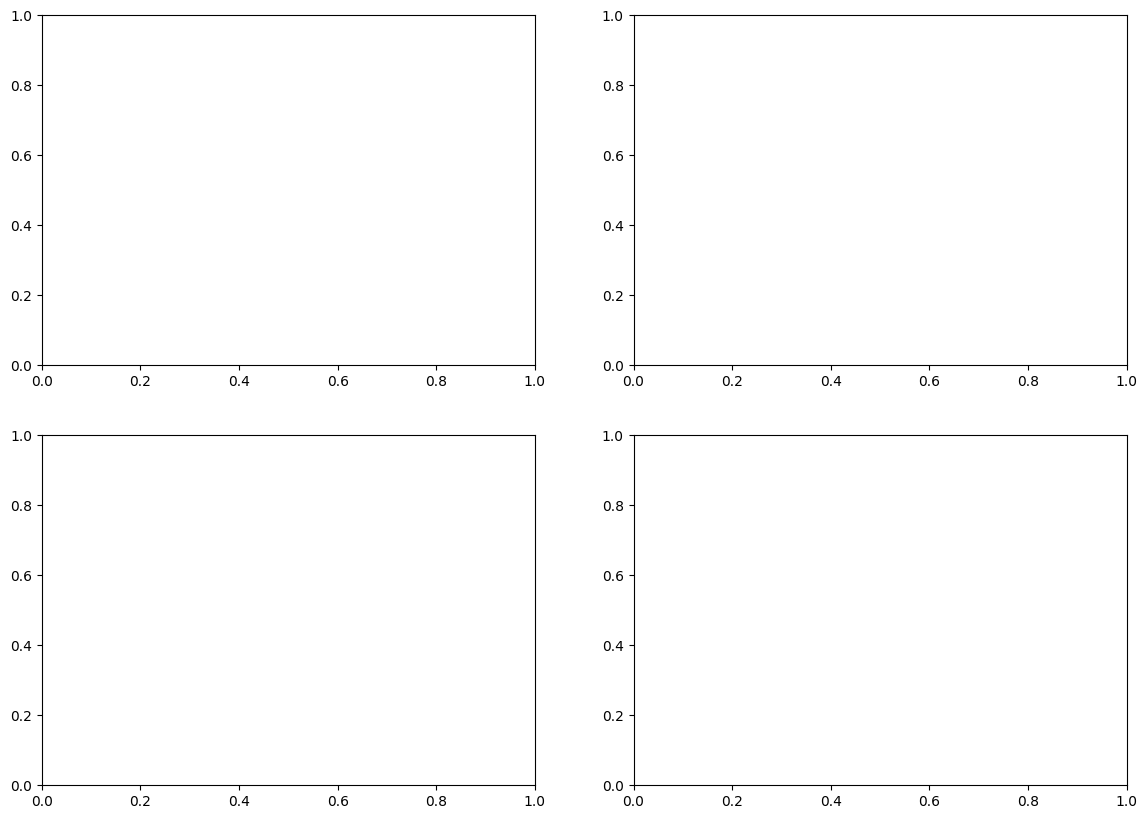

In [10]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = sns.color_palette('viridis', len(model_names))

for i, metric in enumerate(metrics):
    sns.barplot(x='Model', y=metric, data=metrics_df, ax=axes[i], palette=colors)
    axes[i].set_title(f'{metric} Comparison Across Models')
    axes[i].set_ylim(0.9, 1.01) # Set y-limit for better visualization of high scores
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel(metric)

plt.tight_layout()
plt.show()

In [6]:
fig = plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='ROC-AUC', data=metrics_df, palette=colors)
plt.title('ROC-AUC Comparison Across Models')
plt.ylim(0.9, 1.01)
plt.xticks(rotation=45)
plt.ylabel('ROC-AUC Score')
plt.tight_layout()
plt.show()

NameError: name 'sns' is not defined

<Figure size 1000x600 with 0 Axes>

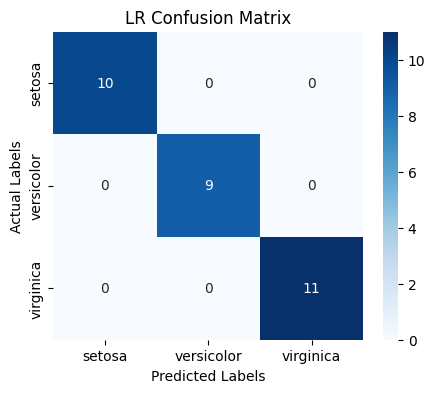

In [ ]:
# --- Confusion Matrices ---

# Logistic Regression Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, LR.predict(X_test)), annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title("LR Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.show()

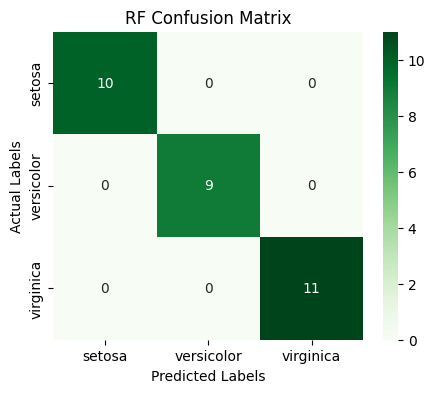

In [ ]:
# Random Forest Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, RF.predict(X_test)), annot=True, fmt='d', cmap='Greens',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title("RF Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.show()

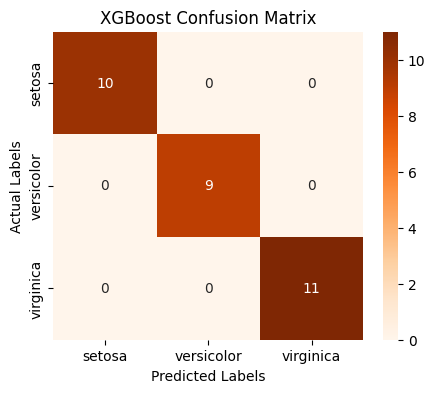

In [ ]:
# XGBoost Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, XGB.predict(X_test)), annot=True, fmt='d', cmap='Oranges',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.show()

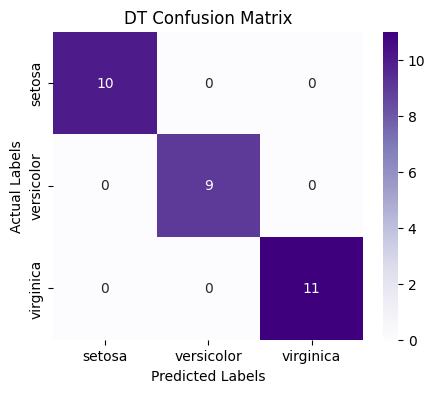

In [ ]:
# Decision Tree Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, DT.predict(X_test)), annot=True, fmt='d', cmap='Purples',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title("DT Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.show()

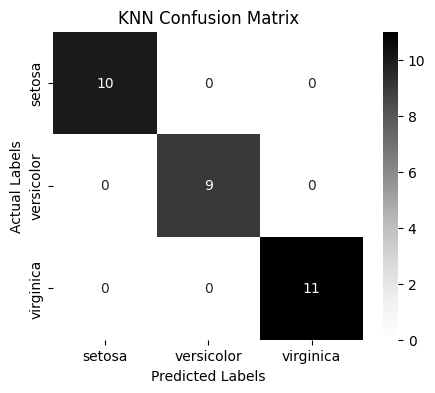

In [ ]:
# K-Nearest Neighbors Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, KNN.predict(X_test)), annot=True, fmt='d', cmap='Greys',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.show()

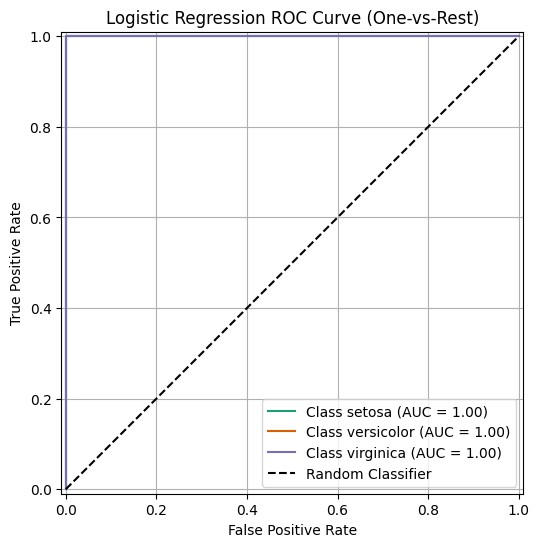

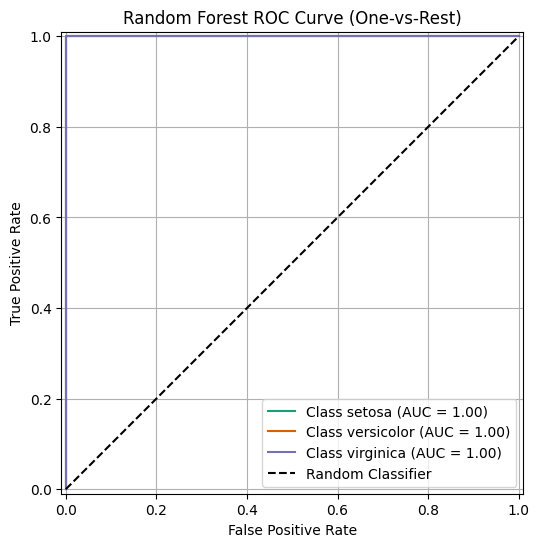

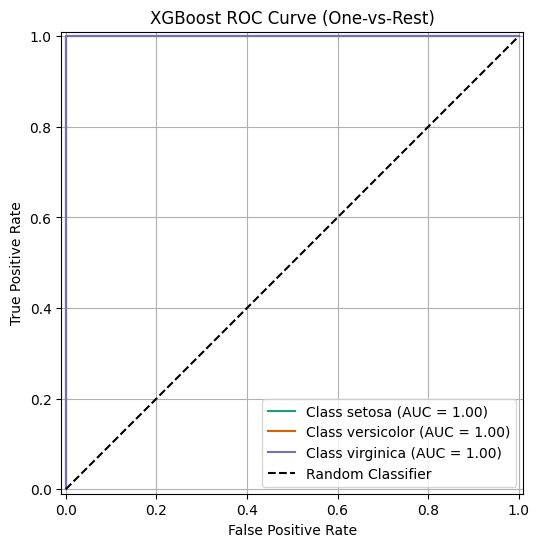

In [ ]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
import numpy as np

target_names = iris.target_names
y_test_binarized = label_binarize(y_test, classes=np.unique(y_train))
n_classes = y_test_binarized.shape[1]
colors = plt.colormaps['Dark2']

# Logistic Regression ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
y_score = LR.predict_proba(X_test)
for i in range(n_classes):
    RocCurveDisplay.from_predictions(
        y_true=y_test_binarized[:, i],
        y_pred=y_score[:, i],
        name=f"Class {target_names[i]}",
        ax=ax,
        color=colors(i)
    )
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_title("Logistic Regression ROC Curve (One-vs-Rest)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
ax.grid(True)
plt.show()

# Random Forest ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
y_score = RF.predict_proba(X_test)
for i in range(n_classes):
    RocCurveDisplay.from_predictions(
        y_true=y_test_binarized[:, i],
        y_pred=y_score[:, i],
        name=f"Class {target_names[i]}",
        ax=ax,
        color=colors(i)
    )
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_title("Random Forest ROC Curve (One-vs-Rest)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
ax.grid(True)
plt.show()

# XGBoost ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
y_score = XGB.predict_proba(X_test)
for i in range(n_classes):
    RocCurveDisplay.from_predictions(
        y_true=y_test_binarized[:, i],
        y_pred=y_score[:, i],
        name=f"Class {target_names[i]}",
        ax=ax,
        color=colors(i)
    )
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_title("XGBoost ROC Curve (One-vs-Rest)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
ax.grid(True)
plt.show()

NameError: name 'DT' is not defined

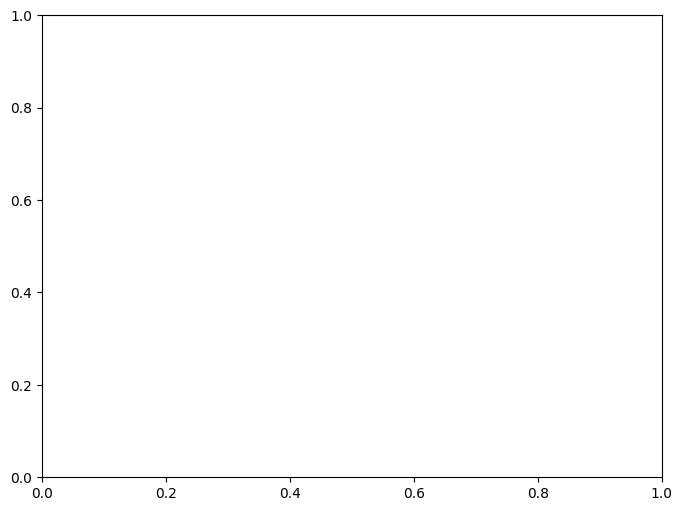

In [7]:
# Decision Tree ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
y_score = DT.predict_proba(X_test)
for i in range(n_classes):
    RocCurveDisplay.from_predictions(
        y_true=y_test_binarized[:, i],
        y_pred=y_score[:, i],
        name=f"Class {target_names[i]}",
        ax=ax,
        color=colors(i)
    )
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_title("Decision Tree ROC Curve (One-vs-Rest)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
ax.grid(True)
plt.show()

NameError: name 'KNN' is not defined

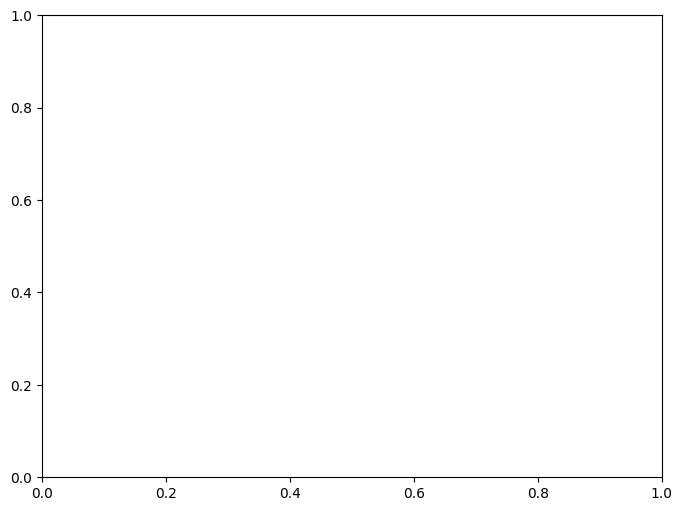

In [8]:
# K-Nearest Neighbors ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
y_score = KNN.predict_proba(X_test)
for i in range(n_classes):
    RocCurveDisplay.from_predictions(
        y_true=y_test_binarized[:, i],
        y_pred=y_score[:, i],
        name=f"Class {target_names[i]}",
        ax=ax,
        color=colors(i)
    )
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_title("K-Nearest Neighbors ROC Curve (One-vs-Rest)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
ax.grid(True)
plt.show()

#### Combined ROC Curves for All Models

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

models = {'Logistic Regression': LR, 'Random Forest': RF, 'XGBoost': XGB, 'Decision Tree': DT, 'K-Nearest Neighbors': KNN}

for model_name, model in models.items():
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)
        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
            auc_score = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f'{model_name} (Class {target_names[i]} AUC = {auc_score:.2f})', color=colors(list(models.keys()).index(model_name) * n_classes + i))

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Combined ROC Curves (One-vs-Rest) for All Models')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

NameError: name 'LR' is not defined

<Figure size 1000x800 with 0 Axes>

In [ ]:
import pickle
import os

output_dir = '/content/drive/MyDrive/python-ml-lab/exp9_10/model_10'
os.makedirs(output_dir, exist_ok=True)

with open(os.path.join(output_dir, 'LR.pkl'),'wb') as file:
    pickle.dump(LR, file)
print('LR Model Saved')

with open(os.path.join(output_dir, 'RF.pkl'),'wb') as file:
    pickle.dump(RF, file)
print('RF Model Saved')

with open(os.path.join(output_dir, 'XGB.pkl'),'wb') as file:
    pickle.dump(XGB, file)
print('XGB Model Saved')

with open(os.path.join(output_dir, 'DT.pkl'),'wb') as file:
    pickle.dump(DT, file)
print('DT Model Saved')

with open(os.path.join(output_dir, 'KNN.pkl'),'wb') as file:
    pickle.dump(KNN, file)
print('KNN Model Saved')

LR Model Saved
RF Model Saved
XGB Model Saved
DT Model Saved
KNN Model Saved
